<a href="https://colab.research.google.com/github/mhawkes2/AML/blob/main/Hawkes_Fishman_Natural_Language_Processing_with_Disaster_Tweets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries & Load Dataset

In [ ]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

import nltk
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.probability import FreqDist

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import KFold, GridSearchCV, train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from scipy.sparse import hstack
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

# Download libraries
for pkg in ["punkt", "stopwords", "wordnet", "omw-1.4", "punkt_tab"]:
    nltk.download(pkg, quiet=True)

sns.set(context='notebook', style='whitegrid')

In [ ]:
# Load the datasets
test_data = pd.read_csv('/content/test.csv')
train_data = pd.read_csv('/content/train.csv')

# Display the first few rows of each dataset to understand their structure
train_data.head(), test_data.head()

(   id keyword location                                               text  \
 0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
 1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
 2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
 3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   
 4   7     NaN      NaN  Just got sent this photo from Ruby #Alaska as ...   
 
    target  
 0       1  
 1       1  
 2       1  
 3       1  
 4       1  ,
    id keyword location                                               text
 0   0     NaN      NaN                 Just happened a terrible car crash
 1   2     NaN      NaN  Heard about #earthquake is different cities, s...
 2   3     NaN      NaN  there is a forest fire at spot pond, geese are...
 3   9     NaN      NaN           Apocalypse lighting. #Spokane #wildfires
 4  11     NaN      NaN      Typhoon Soudelor kills 28 in China and Taiwan)

# Data Preprocessing

In [ ]:
# Stopwords + lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Preprocessing function to clean text data
def clean_text(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@[\w]+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords + very short tokens
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return tokens

# Lightly cleaned raw text: keep stopwords and remove # symbols
# Short tweets rely on context words ("not", "no") and hashtag words for meaning
def clean_text_raw(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@[\w]+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)   # keep hashtag words, strip only the #
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower().strip()
    return text

for df in [train_data, test_data]:
    df['tokens'] = df['text'].apply(clean_text)
    df['tokens'] = df['tokens'].apply(lambda tokens: [t for t in tokens if t != "http"])
    df['cleaned_text'] = df['tokens'].apply(lambda x: ' '.join(x))
    df['cleaned_keyword'] = df['keyword'].str.replace("%20", " ", regex=False)
    # Fully cleaned combined text with keywords and clean tweets
    df['combined_text'] = (
        "keyword: " + df["cleaned_keyword"].fillna("") +
        " tweet: " + df["cleaned_text"].fillna("")
    )
    # Raw combined text for char-level n-gram vectorizer that includes important context
    df['raw_text'] = df['text'].apply(clean_text_raw)
    df['combined_raw'] = (
        df["cleaned_keyword"].fillna("") + " " + df["raw_text"].fillna("")
    ).str.strip()

# Small number of identical tweets have conflicting target labels (0 & 1)
# Resolve by keeping the majority label; if tied, drop both rows to avoid confusing the model
text_label = train_data.groupby('text')['target'].agg(list)
conflicted = text_label[text_label.apply(lambda x: len(set(x)) > 1)].index
for txt in conflicted:
    subset = train_data[train_data['text'] == txt]
    majority = subset['target'].mode()
    if len(majority) == 1:
        # Overwrite all conflicting rows with the majority label
        train_data.loc[train_data['text'] == txt, 'target'] = majority[0]
    else:
        # Genuine tie — drop those rows entirely
        train_data = train_data[train_data['text'] != txt]

train_data = train_data.reset_index(drop=True)
print(f"Training rows after denoising: {len(train_data)}")

# Checking the cleaned text for some examples
train_data[['keyword', 'text', 'combined_text', 'combined_raw']].head(150)

Training rows after denoising: 7589


,keyword,text,combined_text,combined_raw
0,NaN,Our Deeds are the Reason of this #earthquake M...,keyword: tweet: deed reason may allah forgive,our deeds are the reason of this earthquake ma...
1,NaN,Forest fire near La Ronge Sask. Canada,keyword: tweet: forest fire near ronge sask c...,forest fire near la ronge sask canada
2,NaN,All residents asked to 'shelter in place' are ...,keyword: tweet: resident asked shelter place ...,all residents asked to shelter in place are be...
3,NaN,"13,000 people receive #wildfires evacuation or...",keyword: tweet: people receive evacuation ord...,people receive wildfires evacuation orders in ...
4,NaN,Just got sent this photo from Ruby #Alaska as ...,keyword: tweet: got sent photo ruby smoke pou...,just got sent this photo from ruby alaska as s...
...,...,...,...,...
145,airplane%20accident,#Horrible #Accident Man Died In Wings Airplane...,keyword: airplane accident tweet: man died win...,airplane accident horrible accident man died i...
146,airplane%20accident,Experts in France begin examining airplane deb...,keyword: airplane accident tweet: expert franc...,airplane accident experts in france begin exam...
147,airplane%20accident,Experts in France begin examining airplane deb...,keyword: airplane accident tweet: expert franc...,airplane accident experts in france begin exam...
148,airplane%20accident,#KCA #VoteJKT48ID mbataweel: #RIP #BINLADEN Fa...,keyword: airplane accident tweet: mbataweel fa...,airplane accident kca votejktid mbataweel rip ...


# Exploratory Data Analysis

In [ ]:
# Determine shape & number of essays/rows
num_essays = train_data.shape[0]
print("Number of Tweets: "+str(num_essays))

# Check proportions to determine KFold vs StratifiedKFold
counts = train_data["target"].value_counts()
print("\nNumber of tweets with target=0:", counts.get(0, 0))
print("Number of tweets with target=1:", counts.get(1, 0))

proportion_counts = train_data["target"].value_counts(normalize=True)
print("\nNormalized number of tweets with target=0:", proportion_counts.get(0, 0))
print("Normalized Number of tweets with target=1:", proportion_counts.get(1, 0))

# Determine column names
cols = "\nColumn Names: "
for i in range(len(train_data.columns)-1):
  cols += train_data.columns[i]+", "

print(cols+train_data.columns[-1]+"\n")

Number of Tweets: 7589

Number of tweets with target=0: 4334
Number of tweets with target=1: 3255

Normalized number of tweets with target=0: 0.5710897351429701
Normalized Number of tweets with target=1: 0.42891026485702993

Column Names: id, keyword, location, text, target, tokens, cleaned_text, cleaned_keyword, combined_text, raw_text, combined_raw



In [ ]:
# Find the frequency of a word in all the essays
words = [word for essay in train_data['tokens'] for word in essay]
fdist = FreqDist(words)

fdist.most_common(20)

[('fire', 350),
 ('like', 342),
 ('amp', 300),
 ('get', 255),
 ('new', 226),
 ('via', 220),
 ('dont', 206),
 ('one', 205),
 ('people', 197),
 ('time', 170),
 ('video', 168),
 ('emergency', 153),
 ('year', 150),
 ('body', 150),
 ('disaster', 148),
 ('day', 141),
 ('police', 138),
 ('home', 135),
 ('building', 132),
 ('would', 131)]

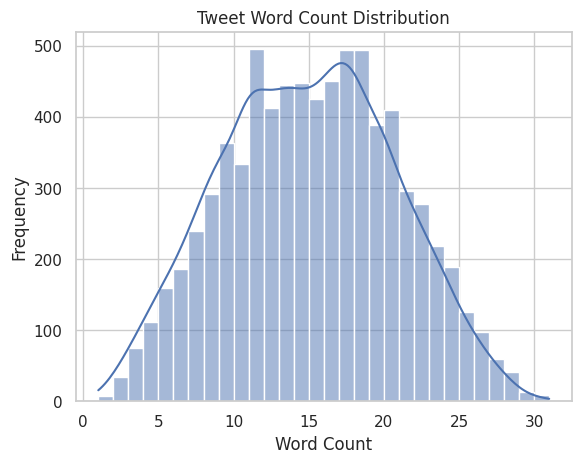

In [ ]:
train_data['word_count'] = train_data['text'].str.split().str.len()

plt.figure()

sns.histplot(
    data=train_data,
    x='word_count',
    bins=30,
    kde=True
)

plt.title("Tweet Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

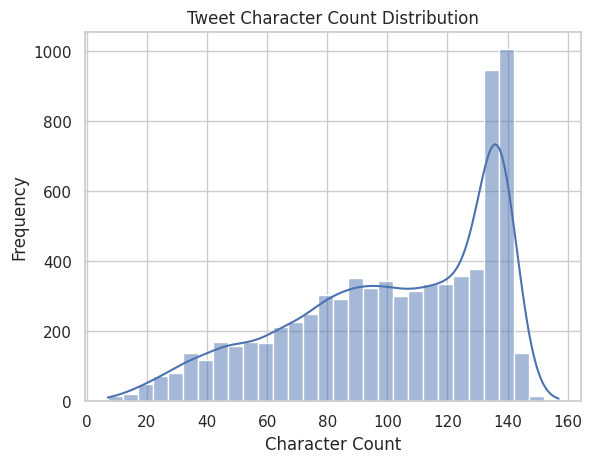

In [ ]:
# Count characters instead of words
train_data['char_count'] = train_data['text'].str.len()

plt.figure()

sns.histplot(
    data=train_data,
    x='char_count',
    bins=30,
    kde=True
)

plt.title("Tweet Character Count Distribution")
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.show()

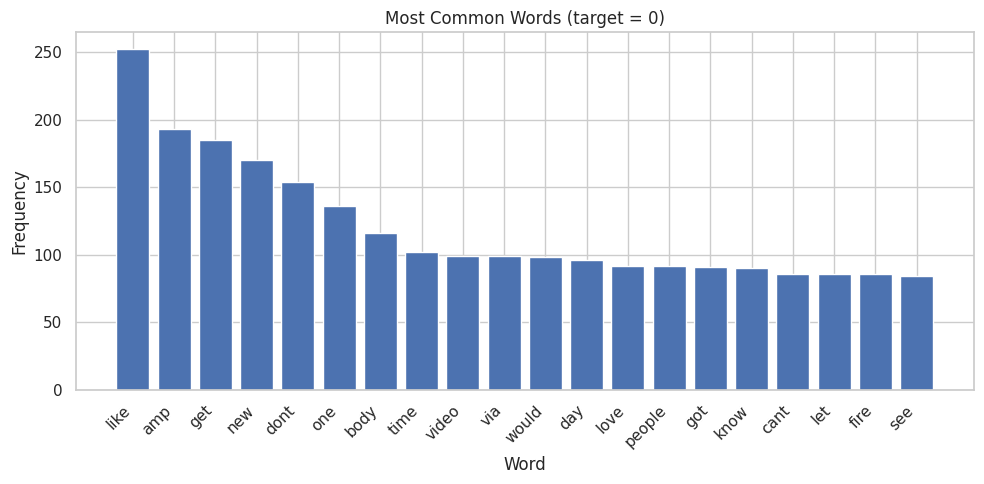

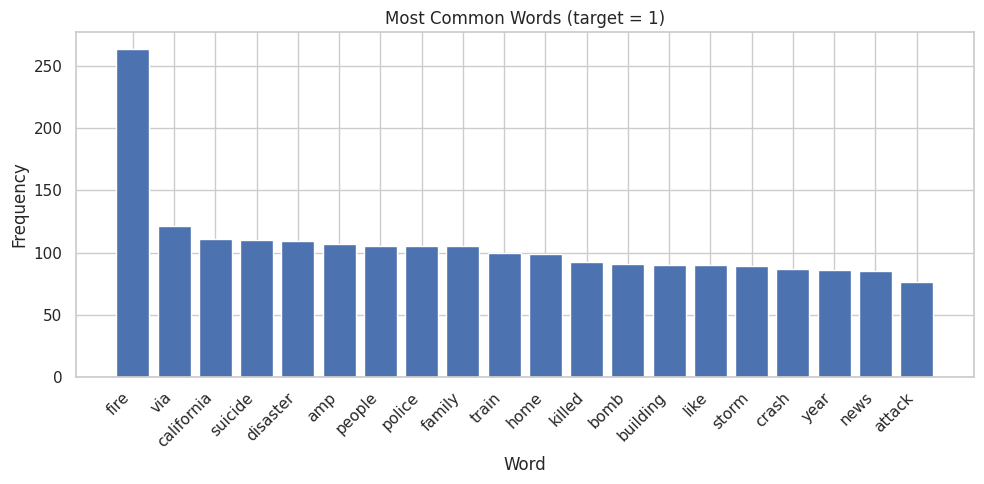

In [ ]:
for val in [0, 1]:
  # filter rows where target == val
  tokens_target_1 = train_data.loc[train_data["target"] == val, "tokens"]

  # flatten all token lists into one list
  all_tokens = [token for tokens in tokens_target_1 for token in tokens]

  # count word frequencies
  word_counts = Counter(all_tokens)

  # get most common words
  common_words = word_counts.most_common(20)  # top 20

  words, counts = zip(*common_words)

  plt.figure(figsize=(10, 5))
  plt.bar(words, counts)
  plt.xticks(rotation=45, ha="right")
  plt.xlabel("Word")
  plt.ylabel("Frequency")
  plt.title("Most Common Words (target = "+str(val)+")")
  plt.tight_layout()
  plt.show()

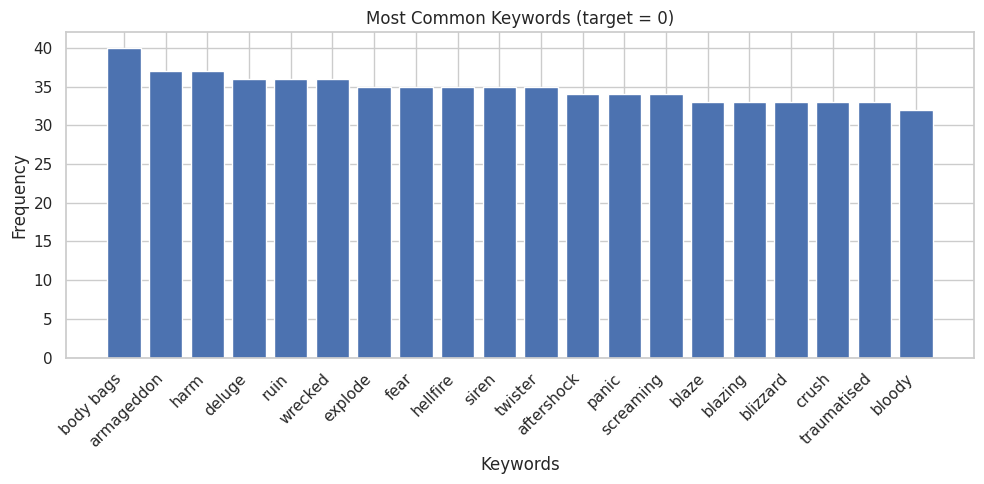

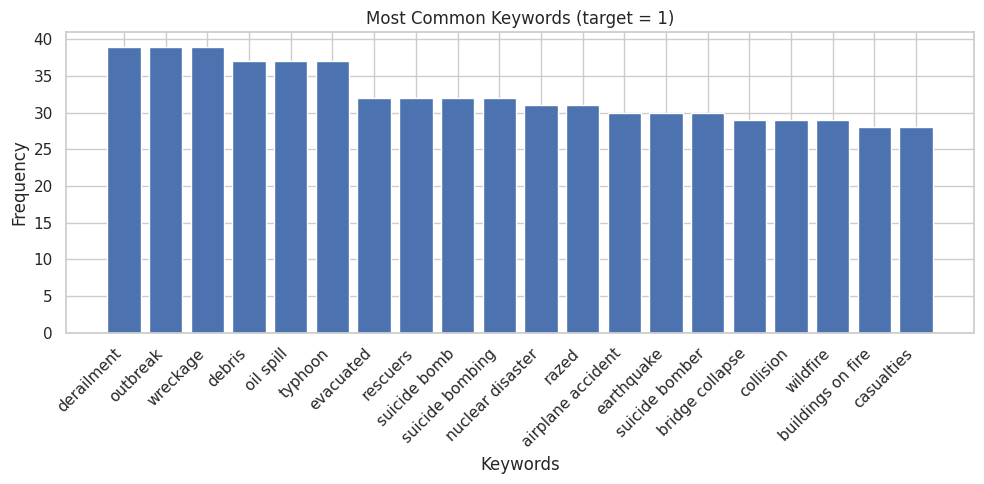

In [ ]:
for val in [0, 1]:
    # filter rows where target == val
    keywords_target = train_data.loc[train_data["target"] == val, "cleaned_keyword"]

    # drop NaNs and force strings
    keywords_target = keywords_target.dropna().astype(str)

    keyword_counts = Counter(keywords_target)
    common_keywords = keyword_counts.most_common(20)

    if common_keywords:
      keywords, counts = zip(*common_keywords)

      plt.figure(figsize=(10, 5))
      plt.bar(keywords, counts)
      plt.xticks(rotation=45, ha="right")
      plt.xlabel("Keywords")
      plt.ylabel("Frequency")
      plt.title(f"Most Common Keywords (target = {val})")
      plt.tight_layout()
      plt.show()

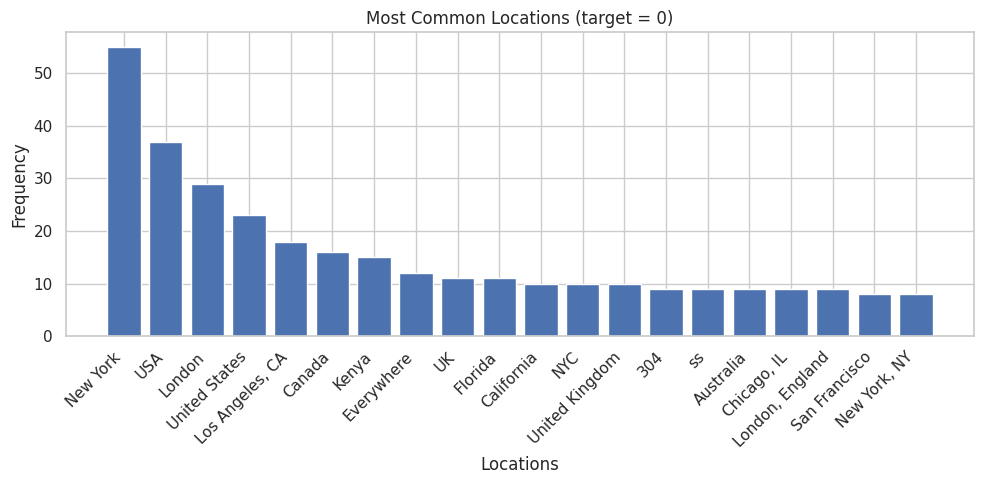

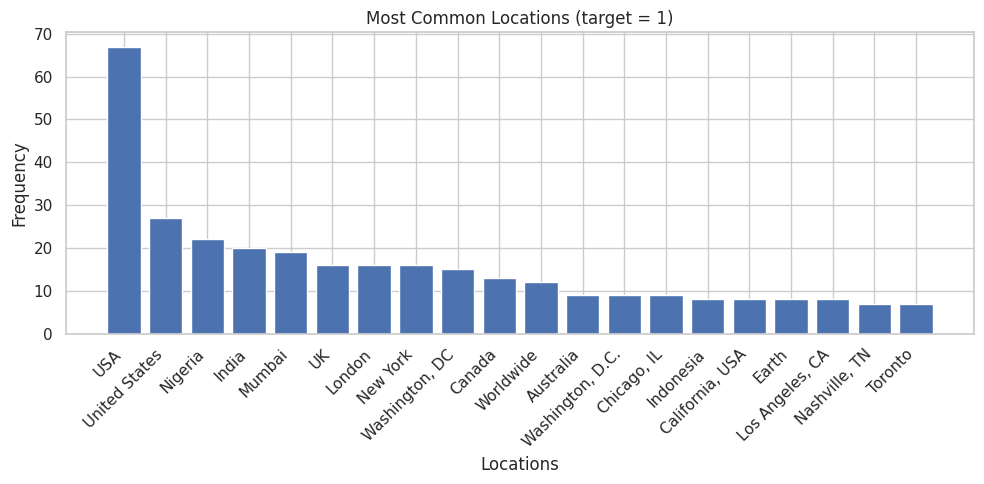

In [ ]:
for val in [0, 1]:
    # filter rows where target == val
    locations_target = train_data.loc[train_data["target"] == val, "location"]

    # drop NaNs and force strings
    locations_target = locations_target.dropna().astype(str)

    location_counts = Counter(locations_target)
    common_locations = location_counts.most_common(20)

    if common_locations:
      locations, counts = zip(*common_locations)

      plt.figure(figsize=(10, 5))
      plt.bar(locations, counts)
      plt.xticks(rotation=45, ha="right")
      plt.xlabel("Locations")
      plt.ylabel("Frequency")
      plt.title(f"Most Common Locations (target = {val})")
      plt.tight_layout()
      plt.show()

# Text Vectorization

In [ ]:
# Four vectorizers (word, longer char, smaller char, keywords) are
# stacked into a single sparse matrix

# Word unigrams + bigrams on lemmatized combined text
word_tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)

# Character (3-5)-grams on raw combined text
char_tfidf_a = TfidfVectorizer(
    analyzer='char_wb',   # char_wb pads each token with spaces — reduces boundary noise
    ngram_range=(3, 5),
    max_features=50000,
    min_df=3,
    sublinear_tf=True
)

# Character (2-4)-grams on raw combined text that captures shorter morphological patterns
char_tfidf_b = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 4),
    max_features=30000,
    min_df=3,
    sublinear_tf=True
)

# Keyword vectorizer which provides high signal to indicate real disaster or fake
kw_tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 1), min_df=1)

# Fit on train and transform both splits
X_word_train  = word_tfidf.fit_transform(train_data['combined_text'])
X_char_a_train = char_tfidf_a.fit_transform(train_data['combined_raw'])
X_char_b_train = char_tfidf_b.fit_transform(train_data['combined_raw'])
X_kw_train    = kw_tfidf.fit_transform(train_data['cleaned_keyword'].fillna(''))

X_word_test   = word_tfidf.transform(test_data['combined_text'])
X_char_a_test  = char_tfidf_a.transform(test_data['combined_raw'])
X_char_b_test  = char_tfidf_b.transform(test_data['combined_raw'])
X_kw_test     = kw_tfidf.transform(test_data['cleaned_keyword'].fillna(''))

# Stack all four into one combined sparse matrix to use for train and test
X_train = hstack([X_word_train, X_char_a_train, X_char_b_train, X_kw_train])
X_test  = hstack([X_word_test,  X_char_a_test,  X_char_b_test,  X_kw_test])

# Target variable (labels) for training
y_train = train_data['target']

print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")

X_train shape: (7589, 58010)
X_test  shape: (3263, 58010)


# Determining the Best Model


Logistic
[[723 153]
 [149 493]]
               precision    recall  f1-score   support

Fake Disaster       0.83      0.83      0.83       876
Real Disaster       0.76      0.77      0.77       642

     accuracy                           0.80      1518
    macro avg       0.80      0.80      0.80      1518
 weighted avg       0.80      0.80      0.80      1518


LinearSVC
[[733 143]
 [152 490]]
               precision    recall  f1-score   support

Fake Disaster       0.83      0.84      0.83       876
Real Disaster       0.77      0.76      0.77       642

     accuracy                           0.81      1518
    macro avg       0.80      0.80      0.80      1518
 weighted avg       0.81      0.81      0.81      1518


DecisionTree
[[716 160]
 [326 316]]
               precision    recall  f1-score   support

Fake Disaster       0.69      0.82      0.75       876
Real Disaster       0.66      0.49      0.57       642

     accuracy                           0.68      1518
    macr

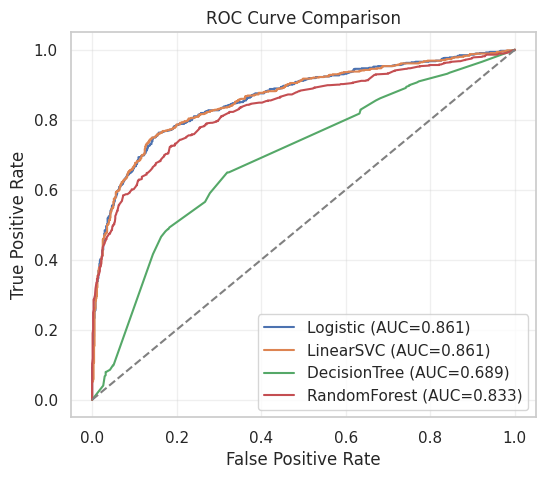

,Model,Accuracy,Precision,Recall,F1-score
1,LinearSVC,0.805665,0.774092,0.763240,0.768627
0,Logistic,0.801054,0.763158,0.767913,0.765528
3,RandomForest,0.778656,0.798828,0.637072,0.708839
2,DecisionTree,0.679842,0.663866,0.492212,0.565295


In [ ]:
# Pipelines for each model
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# All pipelines receive the pre-built sparse TF-IDF matrix directly
pipelines = {
    'Logistic': Pipeline([
        ('model', LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced'))
    ]),
    'LinearSVC': Pipeline([
        ('model', LinearSVC(class_weight='balanced', random_state=42, max_iter=3000, C=0.1))
    ]),
    'DecisionTree': Pipeline([
        ('model', DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=3,
            class_weight='balanced',
            random_state=42
        ))
    ]),
    'RandomForest': Pipeline([
        ('model', RandomForestClassifier(random_state=42, n_estimators=100))
    ]),
}

# Evaluate each model
results = []
for name, pipe in pipelines.items():
    pipe.fit(X_train_split, y_train_split)
    y_pred = pipe.predict(X_val_split)
    acc = accuracy_score(y_val_split, y_pred)
    prec = precision_score(y_val_split, y_pred)
    rec = recall_score(y_val_split, y_pred)
    f1 = f1_score(y_val_split, y_pred)
    results.append([name, acc, prec, rec, f1])

    print(f"\n{name}")
    print(confusion_matrix(y_val_split, y_pred))
    print(classification_report(y_val_split, y_pred, target_names=["Fake Disaster", "Real Disaster"]))

# ROC curve comparison
plt.figure(figsize=(6,5))
for name, pipe in pipelines.items():
    # LinearSVC has no predict_proba, so use decision_function
    if hasattr(pipe.named_steps['model'], "predict_proba"):
        y_score = pipe.predict_proba(X_val_split)[:, 1]
    else:
        y_score = pipe.decision_function(X_val_split)

    fpr, tpr, _ = roc_curve(y_val_split, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")

plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Summary table
df_results = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])
df_results.sort_values("F1-score", ascending=False)

# Hyperparameter Tuning

In [ ]:
RANDOM_STATE = 42

# Stratified CV keeps class balance across every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Tune Logistic Regression
lr_pipe = Pipeline([
    ('model', LogisticRegression(max_iter=2000, solver='lbfgs', random_state=RANDOM_STATE))
])

# Hyperparameter dictionary for LR search range
param_distributions_lr = {
    'model__C':            loguniform(2e-1, 5.0),
    'model__class_weight': [None, 'balanced'],
}

grid_lr = RandomizedSearchCV(
    lr_pipe,
    param_distributions_lr,
    n_iter=40,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

grid_lr.fit(X_train, y_train)

print("Best LR params:", grid_lr.best_params_)
print("Best LR CV F1: ", grid_lr.best_score_)

best_lr = grid_lr.best_estimator_
best_lr.fit(X_train, y_train)

# Tune LinearSVC
svc_pipe = Pipeline([
    ('model', LinearSVC(random_state=RANDOM_STATE, max_iter=3000))
])

# Hyperparameter dictionary for LinearSVC search range
param_distributions_svc = {
    'model__C':            loguniform(3e-2, 3e-1),
    'model__class_weight': [None, 'balanced'],
    'model__loss':         ['hinge', 'squared_hinge'],
    'model__tol':          [1e-2, 1e-3, 1e-4]
}

grid_svc = RandomizedSearchCV(
    svc_pipe,
    param_distributions_svc,
    n_iter=60,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

grid_svc.fit(X_train, y_train)

print("\nBest SVC params:", grid_svc.best_params_)
print("Best SVC CV F1: ", grid_svc.best_score_)

best_svc = grid_svc.best_estimator_
best_svc.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best LR params: {'model__C': np.float64(0.7042214753309837), 'model__class_weight': 'balanced'}
Best LR CV F1:  0.7694792010914467
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best SVC params: {'model__C': np.float64(0.09953034621174876), 'model__class_weight': 'balanced', 'model__loss': 'squared_hinge', 'model__tol': 0.01}
Best SVC CV F1:  0.7717767614773853


Pipeline(steps=[('model',
                 LinearSVC(C=np.float64(0.09953034621174876),
                           class_weight='balanced', max_iter=3000,
                           random_state=42, tol=0.01))])


LogisticRegression (tuned)
[[804  72]
 [ 91 551]]
               precision    recall  f1-score   support

Fake Disaster       0.90      0.92      0.91       876
Real Disaster       0.88      0.86      0.87       642

     accuracy                           0.89      1518
    macro avg       0.89      0.89      0.89      1518
 weighted avg       0.89      0.89      0.89      1518


LinearSVC (tuned)
[[813  63]
 [ 79 563]]
               precision    recall  f1-score   support

Fake Disaster       0.91      0.93      0.92       876
Real Disaster       0.90      0.88      0.89       642

     accuracy                           0.91      1518
    macro avg       0.91      0.90      0.90      1518
 weighted avg       0.91      0.91      0.91      1518



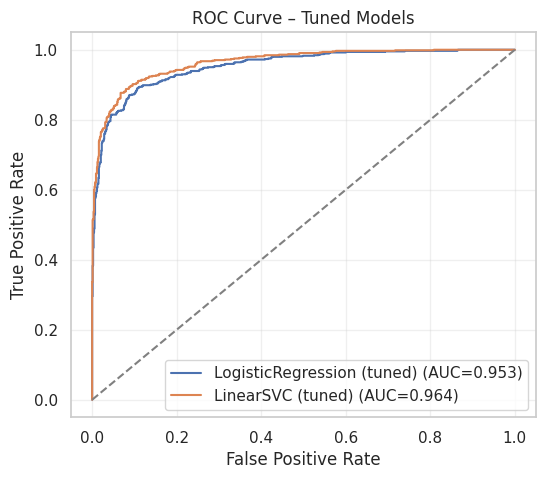

,Model,Accuracy,Precision,Recall,F1-score
1,LinearSVC (tuned),0.906456,0.899361,0.876947,0.888013
0,LogisticRegression (tuned),0.892622,0.884430,0.858255,0.871146


In [ ]:
# Evaluate tuned models to see what performs best
tuned_models = {
    'LogisticRegression (tuned)': best_lr,
    'LinearSVC (tuned)':          best_svc,
}

tuned_results = []
plt.figure(figsize=(6, 5))

for name, model in tuned_models.items():
    y_pred = model.predict(X_val_split)
    acc  = accuracy_score(y_val_split, y_pred)
    prec = precision_score(y_val_split, y_pred)
    rec  = recall_score(y_val_split, y_pred)
    f1   = f1_score(y_val_split, y_pred)
    tuned_results.append([name, acc, prec, rec, f1])

    print(f"\n{name}")
    print(confusion_matrix(y_val_split, y_pred))
    print(classification_report(y_val_split, y_pred, target_names=["Fake Disaster", "Real Disaster"]))

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_val_split)[:, 1]
    else:
        y_score = model.decision_function(X_val_split)
    fpr, tpr, _ = roc_curve(y_val_split, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.3f})")

plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Tuned Models")
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

df_tuned = pd.DataFrame(tuned_results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])
df_tuned.sort_values("F1-score", ascending=False)

# Prediction

In [ ]:
# Select the best tuned model and generate the submission file
best_row  = df_tuned.sort_values("F1-score", ascending=False).iloc[0]
best_name = best_row["Model"]
print(f"Best model selected: {best_name}  (val F1 = {best_row['F1-score']:.4f})")

best_model = tuned_models[best_name]

# Predict
kaggle_preds = best_model.predict(X_test)

# Submission
submission = pd.DataFrame({
    'id': test_data['id'].values,
    'target': kaggle_preds
})
submission.to_csv('submission.csv', index=False)

print(f"\nPrediction distribution on test set:")
print(submission['target'].value_counts())

submission.head()

Best model selected: LinearSVC (tuned)  (val F1 = 0.8880)

Prediction distribution on test set:
target
0    1945
1    1318
Name: count, dtype: int64


,id,target
0,0,1
1,2,0
2,3,1
3,9,1
4,11,1
